In [1]:
import tkinter as tk
from tkinter import filedialog, simpledialog
import pandas as pd
import os

# ============================================================
# 1. Ask for number of conditions
# ============================================================

root = tk.Tk()
root.withdraw()

n_conditions = simpledialog.askinteger(
    "Number of conditions",
    "How many conditions are you analyzing?",
    minvalue=1
)

if n_conditions is None:
    root.destroy()
    raise SystemExit("No number of conditions selected.")


# ============================================================
# 2. Select WGA-GD1a files for each condition
# ============================================================

WGA_GD1a = {}

for condition in range(1, n_conditions + 1):

    file_paths = filedialog.askopenfilenames(
        parent=root,
        title=f"Condition {condition}: Select WGA-GD1a repeats",
        filetypes=[("CSV files", "*.csv")]
    )

    if not file_paths:
        print(f"No WGA-GD1a files selected for condition {condition}.")
        continue

    # Get first filename and remove last 3 characters
    first_filename = os.path.splitext(
        os.path.basename(file_paths[0])
    )[0]

    condition_name = first_filename[:-3]

    WGA_GD1a[condition_name] = {}

    for file_path in file_paths:

        filename = os.path.splitext(
            os.path.basename(file_path)
        )[0]

        try:
            df = pd.read_csv(file_path)
            WGA_GD1a[condition_name][filename] = df

        except Exception as e:
            print(f"Failed to read {filename}: {e}")


# ============================================================
# 3. Select TR-DHPE files for each condition
# ============================================================

TR_DHPE = {}

for condition in range(1, n_conditions + 1):

    file_paths = filedialog.askopenfilenames(
        parent=root,
        title=f"Condition {condition}: Select TR-DHPE repeats",
        filetypes=[("CSV files", "*.csv")]
    )

    if not file_paths:
        print(f"No TR-DHPE files selected for condition {condition}.")
        continue

    # Get first filename and remove last 3 characters
    first_filename = os.path.splitext(
        os.path.basename(file_paths[0])
    )[0]

    condition_name = first_filename[:-3]

    TR_DHPE[condition_name] = {}

    for file_path in file_paths:

        filename = os.path.splitext(
            os.path.basename(file_path)
        )[0]

        try:
            df = pd.read_csv(file_path)
            TR_DHPE[condition_name][filename] = df

        except Exception as e:
            print(f"Failed to read {filename}: {e}")


# ============================================================
# 4. Close Tkinter
# ============================================================

root.destroy()


# ============================================================
# 5. Print summary
# ============================================================

print("\nWGA-GD1a:")
for condition, repeats in WGA_GD1a.items():
    print(f"{condition}: {len(repeats)} repeats")
    for filename in repeats:
        print(f"  - {filename}")

print("\nTR-DHPE:")
for condition, repeats in TR_DHPE.items():
    print(f"{condition}: {len(repeats)} repeats")
    for filename in repeats:
        print(f"  - {filename}")


WGA-GD1a:
0% SM: 3 repeats
  - 0% SM r1
  - 0% SM r2
  - 0% SM r3
5% SM: 3 repeats
  - 5% SM r1
  - 5% SM r2
  - 5% SM r3
10% SM: 3 repeats
  - 10% SM r1
  - 10% SM r2
  - 10% SM r3
20% SM: 3 repeats
  - 20% SM r1
  - 20% SM r2
  - 20% SM r3

TR-DHPE:
0% SM: 3 repeats
  - 0% SM r1
  - 0% SM r2
  - 0% SM r3
5% SM: 6 repeats
  - 5% SM r1
  - 5% SM r2
  - 5% SM r3
  - 5% SM r4
  - 5% SM r5
  - 5% SM r6
10% SM: 3 repeats
  - 10% SM r1
  - 10% SM r2
  - 10% SM r3
20% SM: 3 repeats
  - 20% SM r1
  - 20% SM r2
  - 20% SM r3


In [2]:
import numpy as np
import pandas as pd

# ============================================================
# Function to normalize, remove pre-bleach frames,
# and reset time to zero
# ============================================================

def normalize_prebleach(data_dict, dict_name):

    print(f"\n{'=' * 60}")
    print(f"{dict_name}")
    print(f"{'=' * 60}")

    for condition, repeats in data_dict.items():

        print(f"\n{condition}:")

        for repeat_name, df in repeats.items():

            # Get intensity values
            intensity = df["bleach spot intensity"].to_numpy()

            # Find the largest drop between consecutive frames
            intensity_change = np.diff(intensity)

            # First post-bleach frame
            first_post_bleach = np.argmin(intensity_change) + 1

            # Pre-bleach intensity
            prebleach_intensity = intensity[:first_post_bleach]

            # Mean pre-bleach intensity
            prebleach_mean = np.mean(prebleach_intensity)

            # Normalize all intensity values to pre-bleach mean
            normalized_intensity = intensity / prebleach_mean

            # Create normalized copy of dataframe
            df_normalized = df.copy()

            df_normalized["bleach spot intensity"] = normalized_intensity

            # Remove pre-bleach frames
            df_normalized = df_normalized.iloc[first_post_bleach:].copy()

            # Reset index
            df_normalized.reset_index(drop=True, inplace=True)

            # ====================================================
            # Reset time so first post-bleach frame = 0 s
            # ====================================================

            first_time = df_normalized["time (s)"].iloc[0]

            df_normalized["time (s)"] = (
                df_normalized["time (s)"] - first_time
            )

            # Overwrite dataset in dictionary
            data_dict[condition][repeat_name] = df_normalized

            # Print information
            print(
                f"  {repeat_name}: "
                f"first post-bleach frame = {first_post_bleach}, "
                f"original time = {first_time:.2f} s, "
                f"pre-bleach mean = {prebleach_mean:.2f}, "
                f"remaining frames = {len(df_normalized)}"
            )


# ============================================================
# Apply to both dictionaries
# ============================================================

normalize_prebleach(WGA_GD1a, "WGA-GD1a")
normalize_prebleach(TR_DHPE, "TR-DHPE")


WGA-GD1a

0% SM:
  0% SM r1: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 2597.89, remaining frames = 301
  0% SM r2: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3107.30, remaining frames = 301
  0% SM r3: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3321.41, remaining frames = 301

5% SM:
  5% SM r1: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3517.56, remaining frames = 301
  5% SM r2: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3502.55, remaining frames = 301
  5% SM r3: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 4351.71, remaining frames = 301

10% SM:
  10% SM r1: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3504.86, remaining frames = 301
  10% SM r2: first post-bleach frame = 6, original time = 0.60 s, pre-bleach mean = 3494.85, remaining frames = 301
  10% SM r3: first post-bleach frame = 6, o

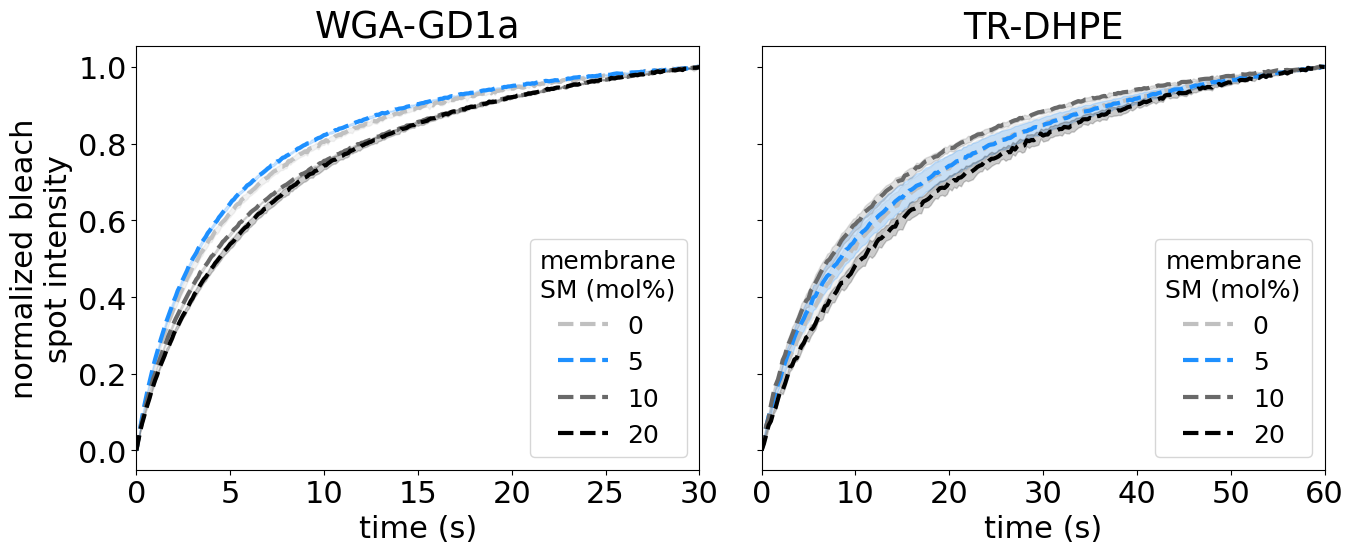

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Function to min-max normalize each repeat
# ============================================================

def minmax_normalize_frap(data_dict):

    normalized_dict = {}

    for condition, repeats in data_dict.items():

        normalized_dict[condition] = {}

        for repeat_name, df in repeats.items():

            df_normalized = df.copy()

            intensity = df["bleach spot intensity"].to_numpy()

            # First and last values
            first_value = intensity[0]
            last_value = intensity[-1]

            # Min-max normalization
            normalized_intensity = (
                (intensity - first_value)
                / (last_value - first_value)
            )

            df_normalized["bleach spot intensity"] = normalized_intensity

            normalized_dict[condition][repeat_name] = df_normalized

    return normalized_dict


# ============================================================
# Normalize each repeat independently
# ============================================================

WGA_GD1a_minmax = minmax_normalize_frap(WGA_GD1a)
TR_DHPE_minmax = minmax_normalize_frap(TR_DHPE)


# ============================================================
# Function to calculate mean ± SEM at each time point
# ============================================================

def summarize_frap(data_dict):

    summary = {}

    for condition, repeats in data_dict.items():

        intensity_data = []

        for repeat_name, df in repeats.items():
            intensity_data.append(
                df["bleach spot intensity"].to_numpy()
            )

        intensity_data = np.array(intensity_data)

        mean_intensity = np.mean(intensity_data, axis=0)

        sem_intensity = (
            np.std(intensity_data, axis=0, ddof=1)
            / np.sqrt(intensity_data.shape[0])
        )

        time = next(iter(repeats.values()))["time (s)"].to_numpy()

        summary[condition] = pd.DataFrame({
            "time (s)": time,
            "mean bleach spot intensity": mean_intensity,
            "SEM bleach spot intensity": sem_intensity
        })

    return summary


# ============================================================
# Create normalized summary dictionaries
# ============================================================

WGA_GD1a_minmax_summary = summarize_frap(WGA_GD1a_minmax)
TR_DHPE_minmax_summary = summarize_frap(TR_DHPE_minmax)


# ============================================================
# Color scheme
# ============================================================

colors = [
    "silver",
    "tan",
    "dodgerblue",
    "forestgreen"
]

colors = [
    "silver",
    "dodgerblue",
    "dimgrey",
    "black"
]

# ============================================================
# Legend labels
# ============================================================

legend_labels = ["0", "5", "10", "20"]

# ============================================================
# Global font size
# ============================================================

plt.rcParams.update({'font.size': 22})


# ============================================================
# Create two plots next to each other
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=True
)


# ============================================================
# Plot 1: WGA-GD1a
# ============================================================

ax = axes[0]

for i, (condition, df) in enumerate(
    WGA_GD1a_minmax_summary.items()
):

    color = colors[i]

    ax.plot(
        df["time (s)"],
        df["mean bleach spot intensity"],
        label=legend_labels[i],
        color=color,
        linestyle="--",
        linewidth=3
    )

    ax.fill_between(
        df["time (s)"],
        df["mean bleach spot intensity"]
        - df["SEM bleach spot intensity"],
        df["mean bleach spot intensity"]
        + df["SEM bleach spot intensity"],
        color=color,
        alpha=0.2
    )


ax.set_title("WGA-GD1a")
ax.set_xlabel("time (s)")
ax.set_ylabel("normalized bleach\nspot intensity")

# X-axis range: 0–30 s
ax.set_xlim(0, 30)

ax.legend(
    title="membrane\nSM (mol%)",
    fontsize=18,
    title_fontsize=18
)


# ============================================================
# Plot 2: TR-DHPE
# ============================================================

ax = axes[1]

for i, (condition, df) in enumerate(
    TR_DHPE_minmax_summary.items()
):

    color = colors[i]

    ax.plot(
        df["time (s)"],
        df["mean bleach spot intensity"],
        label=legend_labels[i],
        color=color,
        linestyle="--",
        linewidth=3
    )

    ax.fill_between(
        df["time (s)"],
        df["mean bleach spot intensity"]
        - df["SEM bleach spot intensity"],
        df["mean bleach spot intensity"]
        + df["SEM bleach spot intensity"],
        color=color,
        alpha=0.2
    )


ax.set_title("TR-DHPE")
ax.set_xlabel("time (s)")

# X-axis range: 0–60 s
ax.set_xlim(0, 60)

ax.legend(
    title="membrane\nSM (mol%)",
    fontsize=18,
    title_fontsize=18
)


# ============================================================
# Formatting
# ============================================================

plt.tight_layout()


# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "/Users/steinar/Desktop/FRAP recovery curves.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()